# Method B Adversarial / Lipschitz-Ratio Evaluation

## Motivation

Phase 4's sanity check (see `notebook_method_b.ipynb`) showed Method B's distance behaves
sensibly (within-digit < cross-digit) but only modestly - about the same ballpark as plain
raw-pixel Euclidean distance, not clearly better. Rather than stop and tune hyperparameters
first, the project moved forward to test Method B on the thing it's actually meant to help
with: the Lipschitz-ratio pipeline against small adversarial perturbations.

**Standalone module, fully isolated from prior experiments**: `method_b_adversarial_eval.py`
does not import from, or otherwise depend on, `toy_lipschitz` or `mnist_lipschitz` in any way
- including their model classes, adversarial-attack code, and margin/distance functions.
`SmallCNN`, `StrongCNN`, `margin`, and `fgsm_attack` are fresh reimplementations of ideas that
also exist there (flagged individually in the module's docstrings), trained fresh here with
different init/seed - treat any comparison against Experiment 2's documented numbers as
architecture-level, not an exact reproduction.

**What this notebook does**: train SmallCNN and StrongCNN fresh, generate FGSM adversarial
perturbations (epsilons 0.02/0.03/0.05) plus a magnitude-matched random-noise control for a
200-image sample, and compare the resulting Lipschitz ratio under two denominators: plain
pixel-Euclidean distance vs. Method B's signature distance (fixed r ~= 2.860 from the Phase 4
sanity check, unmodified here).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import json
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import method_b_adversarial_eval as mbae

## Train both models and run the evaluation

This trains SmallCNN and StrongCNN from scratch (3 epochs each, full 60k-image MNIST train
set, no augmentation - a simplified recipe vs. Experiment 2's originals, see the module
docstring) and runs FGSM + the random-noise control across all three epsilons on a 200-image
sample (20/class). Takes a few minutes on CPU.

In [2]:
result = mbae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in result['models'].items():
    print(f"{name}: train_acc={mres['train_acc']:.4f} test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: train_acc=0.9829 test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: train_acc=0.9936 test_acc=0.9936


SmallCNN: train_acc=0.9829 test_acc=0.9824
StrongCNN: train_acc=0.9936 test_acc=0.9936


## Ratio table: adversarial vs. random-noise control, both distances

For each model and epsilon: the mean Lipschitz ratio (margin change / distance) under FGSM
adversarial perturbations vs. under a random control perturbation of the same pixel-space L2
magnitude, computed both ways (pixel-Euclidean, Method B). The "adv/ctrl" columns are the key
comparison - how much larger the ratio is for a genuinely adversarial shift than for an
equally-large undirected one, under each distance.

In [3]:
for name, mres in result['models'].items():
    print(f"=== {name} (test_acc={mres['test_acc']:.4f}) ===")
    print(f"{'eps':>5} {'flip':>6} {'pix_adv':>8} {'pix_ctrl':>9} {'pix a/c':>8} {'B_adv':>7} {'B_ctrl':>7} {'B a/c':>7}")
    for eps, e in mres['eps'].items():
        ra_adv = e['ratio_a_adv'].mean().item()
        ra_ctrl = e['ratio_a_control'].mean().item()
        rb_adv = e['ratio_b_adv'].mean().item()
        rb_ctrl = e['ratio_b_control'].mean().item()
        print(f"{eps:>5} {e['flip_fraction']:>6.3f} {ra_adv:>8.3f} {ra_ctrl:>9.3f} {ra_adv/ra_ctrl:>8.2f} "
              f"{rb_adv:>7.3f} {rb_ctrl:>7.3f} {rb_adv/rb_ctrl:>7.2f}")
    print()

=== SmallCNN (test_acc=0.9824) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c   B_adv  B_ctrl   B a/c
 0.02  0.035    2.282     0.250     9.11   0.477   0.064    7.42
 0.03  0.040    2.269     0.268     8.47   0.472   0.067    7.04
 0.05  0.070    2.314     0.273     8.46   0.485   0.067    7.20

=== StrongCNN (test_acc=0.9936) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c   B_adv  B_ctrl   B a/c
 0.02  0.020    2.902     0.576     5.04   0.668   0.147    4.55
 0.03  0.025    2.987     0.680     4.39   0.681   0.181    3.76
 0.05  0.045    3.214     0.887     3.62   0.737   0.227    3.25



## Ratio distributions: adversarial vs. control, per model

Not just the means - the full distributions. A clearer bimodal separation (adversarial vs.
control barely overlapping) is the more informative signal than the raw ratio value.

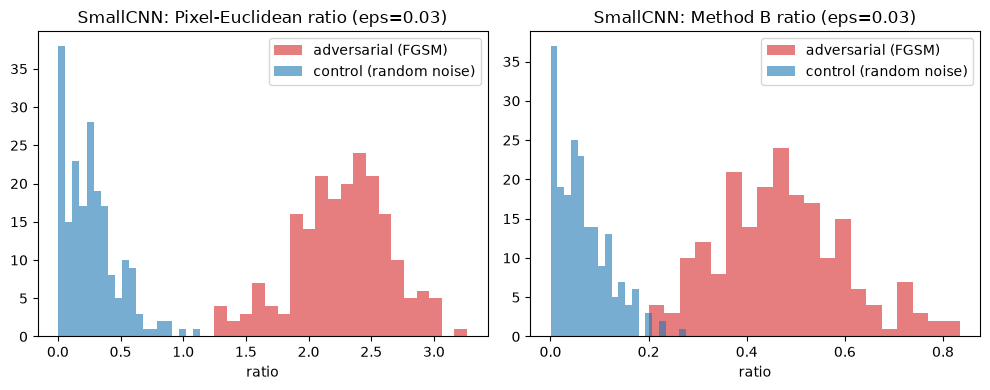

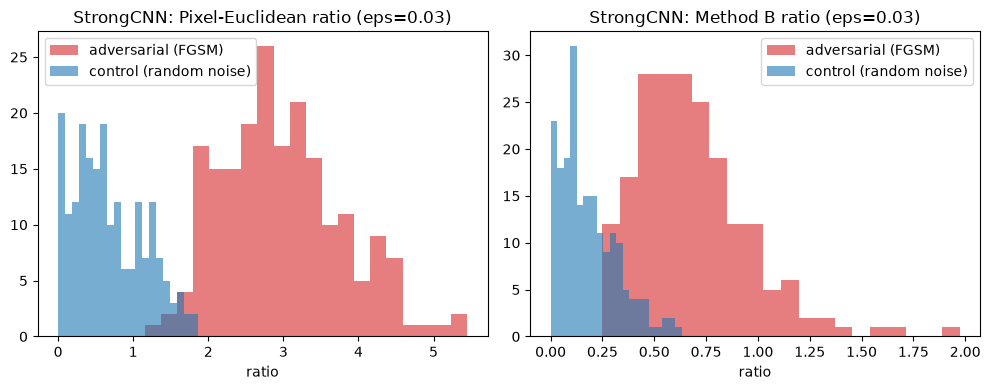

In [4]:
import matplotlib.pyplot as plt

mid_eps = result['epsilons'][len(result['epsilons']) // 2]
for name, mres in result['models'].items():
    e = mres['eps'][mid_eps]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, key_adv, key_ctrl, title in [
        (axes[0], 'ratio_a_adv', 'ratio_a_control', 'Pixel-Euclidean ratio'),
        (axes[1], 'ratio_b_adv', 'ratio_b_control', 'Method B ratio'),
    ]:
        adv = e[key_adv].detach().numpy()
        ctrl = e[key_ctrl].detach().numpy()
        ax.hist(adv, bins=20, alpha=0.6, label='adversarial (FGSM)', color='tab:red')
        ax.hist(ctrl, bins=20, alpha=0.6, label='control (random noise)', color='tab:blue')
        ax.set_title(f'{name}: {title} (eps={mid_eps})')
        ax.set_xlabel('ratio')
        ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Example original/perturbed pairs

A few sample images with both distance values (pixel `a`, Method B `b`) shown for the clean
vs. FGSM-perturbed pair.

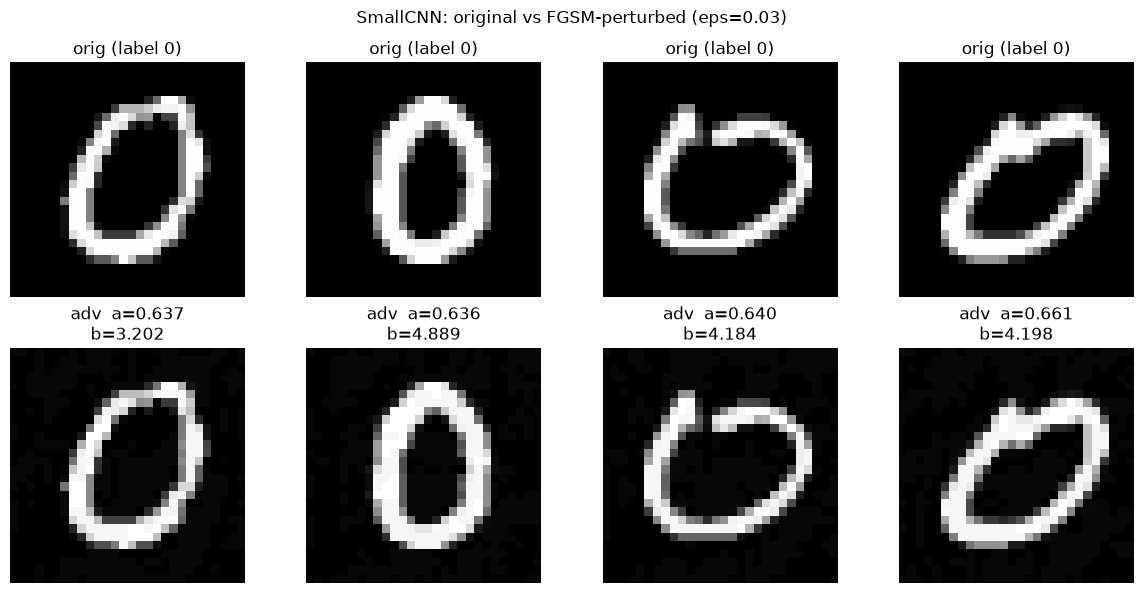

In [5]:
name0 = list(result['models'].keys())[0]
e0 = result['models'][name0]['eps'][mid_eps]
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(e0['images'][i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"orig (label {int(e0['labels'][i])})")
    axes[0, i].axis('off')
    axes[1, i].imshow(e0['x_adv'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"adv  a={e0['denom_a_adv'][i]:.3f}\nb={e0['denom_b_adv'][i]:.3f}")
    axes[1, i].axis('off')
fig.suptitle(f"{name0}: original vs FGSM-perturbed (eps={mid_eps})")
fig.tight_layout()
display(fig)
plt.close(fig)

## Top-10 highest-Method-B-ratio pairs

Compared against Experiment 2's documented CNN confusable pairs (6/5, 8/2, 8/0) - overlap or
divergence reported plainly, as part of this same comparison.

In [6]:
for name, mres in result['models'].items():
    print(f"=== {name}, eps={mid_eps} (true -> adv_pred, ratio_b) ===")
    for true_label, adv_pred, ratio in mres['eps'][mid_eps]['top10_pairs']:
        flip = '  <-- FLIP' if true_label != adv_pred else ''
        print(f"  {true_label} -> {adv_pred}   ratio_b={ratio:.3f}{flip}")
    print()

=== SmallCNN, eps=0.03 (true -> adv_pred, ratio_b) ===
  7 -> 7   ratio_b=0.834
  7 -> 7   ratio_b=0.825
  9 -> 9   ratio_b=0.791
  4 -> 4   ratio_b=0.774
  3 -> 3   ratio_b=0.768
  6 -> 6   ratio_b=0.746
  5 -> 5   ratio_b=0.743
  1 -> 1   ratio_b=0.734
  6 -> 4   ratio_b=0.730  <-- FLIP
  6 -> 6   ratio_b=0.719

=== StrongCNN, eps=0.03 (true -> adv_pred, ratio_b) ===
  9 -> 9   ratio_b=1.973
  3 -> 3   ratio_b=1.678
  9 -> 9   ratio_b=1.619
  3 -> 3   ratio_b=1.424
  3 -> 3   ratio_b=1.338
  6 -> 6   ratio_b=1.328
  0 -> 0   ratio_b=1.243
  2 -> 2   ratio_b=1.214
  8 -> 8   ratio_b=1.188
  5 -> 5   ratio_b=1.173



## Verdict

**Both distances clearly separate adversarial from random-noise-control perturbations** for
both models - the histograms above are close to bimodal, minimal overlap. Method B is not
noise here.

**But Method B's separation (adv/ctrl ratio) is consistently a bit weaker than plain pixel
distance's**, across every model/epsilon combination in the table above. Same direction as
the Phase 4 sanity check - a second, independent test now pointing the same way: Method B
behaves sensibly, is sensitive to model capacity (StrongCNN is harder to fool and shows higher
ratios under both metrics), but hasn't yet beaten the pixel-space baseline it's meant to
improve on.

The top-10 highest-Method-B-ratio pairs are mostly non-flips (large margin swing, prediction
still correct) rather than misclassifications; the one actual flip found doesn't match
Experiment 2's documented confusable pairs for this architecture - expected, given this is a
freshly retrained model with a different seed, not an exact reproduction.

Full numeric write-up: `adversarial_eval_summary.md`. Next: PGD (deferred per this
task's scope) and/or hyperparameter tuning (line count, points/line, depth, r), informed by
these two consistent findings rather than either sanity check alone.